In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

In [5]:
insurance_df = pd.read_csv("c:\\Users\\donat\\iCloudDrive\\Documents\\BIT Data Analytics\\practice\\VSCode\\data/insurance.csv")

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### EDA

<Axes: xlabel='charges', ylabel='Count'>

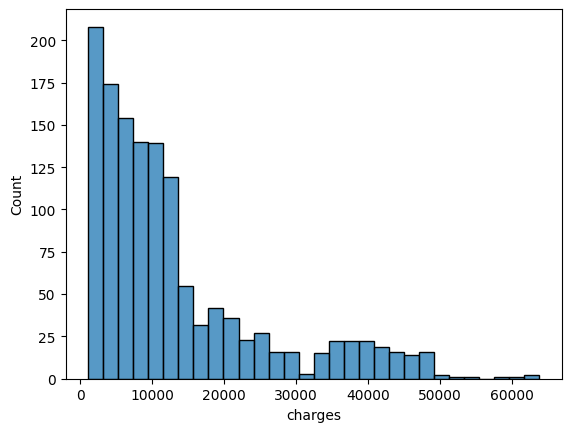

In [6]:
sns.histplot(insurance_df["charges"])

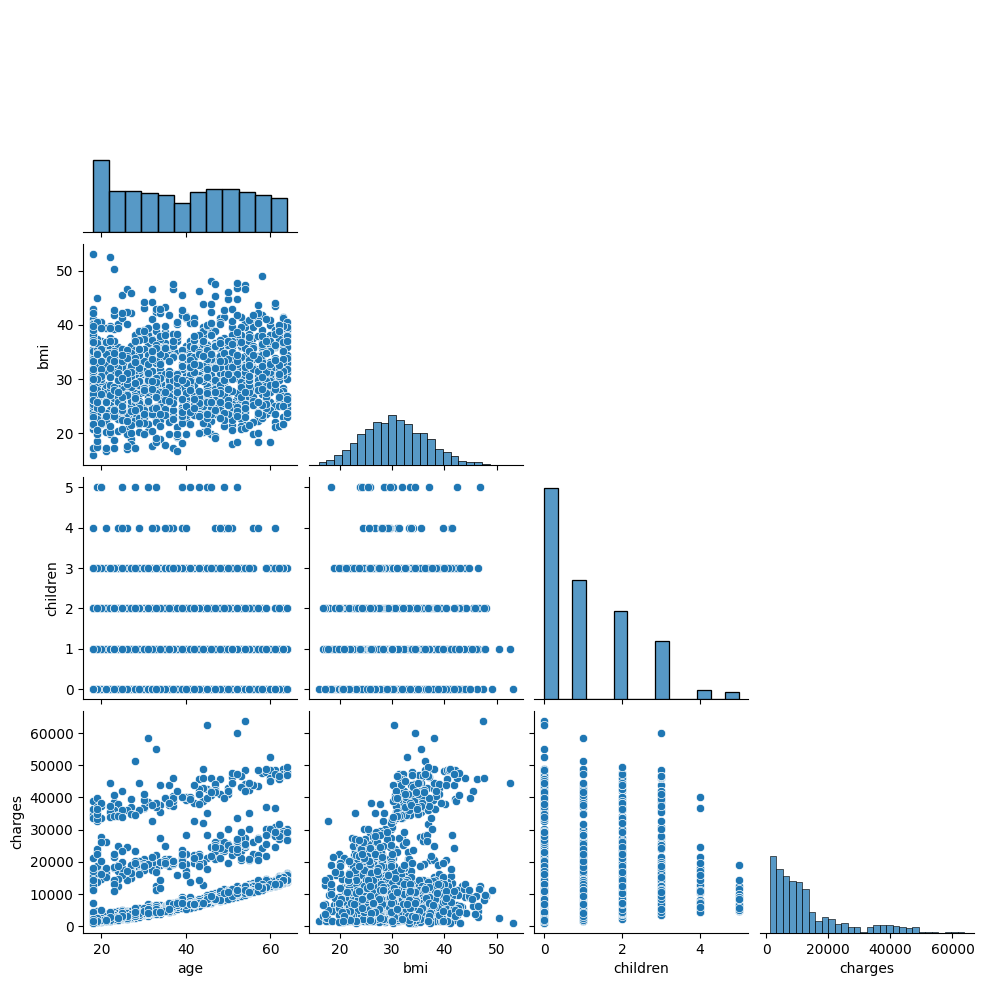

In [7]:
sns.pairplot(insurance_df, corner=True)

In [8]:
insurance_df.corr(numeric_only=True).round(3)

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


<Axes: >

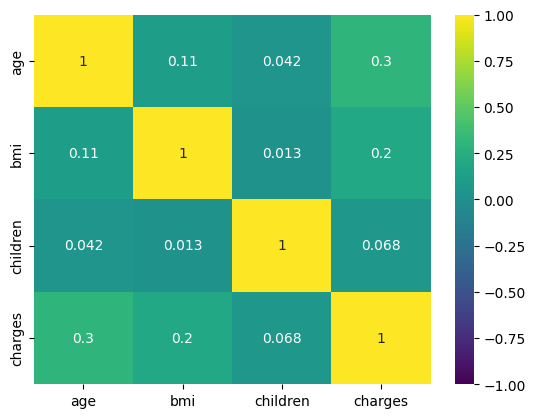

In [9]:
sns.heatmap(insurance_df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="viridis")

### Fitting the Model

In [10]:
X = sm.add_constant(insurance_df["age"])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     131.2
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           4.89e-29
Time:                        19:45:22   Log-Likelihood:                -14415.
No. Observations:                1338   AIC:                         2.883e+04
Df Residuals:                    1336   BIC:                         2.884e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3165.8850    937.149      3.378      0.001    1327.440    5004.330
age          257.7226     22.502     11.453      0.000     213.579     301.866
==============================================================================
Omnibus:                      399.600   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              864.239
Skew:                           1.733   Prob(JB):                    2.15e-188
Kurtosis:                       4.869   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

charges konstanta 3165.88, auga kas metus pagal amžių po 257.72 USD

std err - 937.15 USD

#### OLS regresijos interpretacija (charges ~ age)

Modelio kokybė

- **R-squared = 0.089**  
  Amžius paaiškina tik apie **8.9%** draudimo išlaidų variacijos.  
  Modelis silpnas – daug variacijos lieka nepaaiškinta.

- **F-statistic p-value < 0.001**  
  Modelis statistiškai reikšmingas.  
  Tai reiškia, kad amžius turi ryšį su išlaidomis, bet ryšys nėra stiprus.


Koeficientai

- **Intercept (3165.89)**  
  Prognozuojamos išlaidos, kai amžius = 0.  - čia - 18 metų

- **age = 257.72 (p < 0.001)**  
  Kiekvienais papildomais metais draudimo išlaidos vidutiniškai didėja apie **258 vienetais**.  
  Ryšys statistiškai reikšmingas.



### Išvada

Amžius turi statistiškai reikšmingą teigiamą poveikį draudimo išlaidoms, tačiau vien tik amžius yra **nepakankamas paaiškinti išlaidų pokyčius**. Reikalingi papildomi kintamieji (BMI, rūkymas, vaikai ir kt.).

### Making Predictions

In [11]:
customer_ages = [18, 25, 35, 45, 55]

X_predict = sm.add_constant(pd.DataFrame({"age": customer_ages}))

X_predict

,const,age
0,1.0,18
1,1.0,25
2,1.0,35
3,1.0,45
4,1.0,55


In [12]:
predictions = model.predict(X_predict)

predictions.name = "predictions"

In [13]:
predictions 

0     7804.892142
1     9608.950473
2    12186.176659
3    14763.402846
4    17340.629033
Name: predictions, dtype: float64

In [14]:
## Compare predictions to actual values

(insurance_df
 .query("age in @customer_ages")
 .groupby("age")
 .agg({"charges": "mean"})
 .reset_index()
 .merge(predictions, left_index=True, right_index=True)
 .assign(
     error = lambda x: x["predictions"] - x["charges"],
     pct_difference = lambda x: (x["error"] / x["charges"]) * 100
 
 )
)

,age,charges,predictions,error,pct_difference
0,18,7086.217556,7804.892142,718.674586,10.141865
1,25,9838.365311,9608.950473,-229.414838,-2.331839
2,35,11307.182031,12186.176659,878.994628,7.773773
3,45,14830.199856,14763.402846,-66.797010,-0.450412
4,55,16164.545488,17340.629033,1176.083544,7.275698


#### Interpretacija

- 18 m. asmeniui modelis **pervertino** išlaidas apie 10%.  
- 25 m. asmeniui modelis **nuvertino** išlaidas apie 2%.  
- 35 m. ir 55 m. atvejais matomas reikšmingas pervertinimas (~7–8%).  
- 45 m. atvejis prognozuotas beveik tiksliai (<1% paklaida).

Tai rodo, kad paprasta regresija (tik su amžiumi) ne visada tiksliai atspindi realias išlaidas – galimai trūksta kitų svarbių kintamųjų (pvz., BMI, rūkymas, vaikai).

<Axes: ylabel='None'>

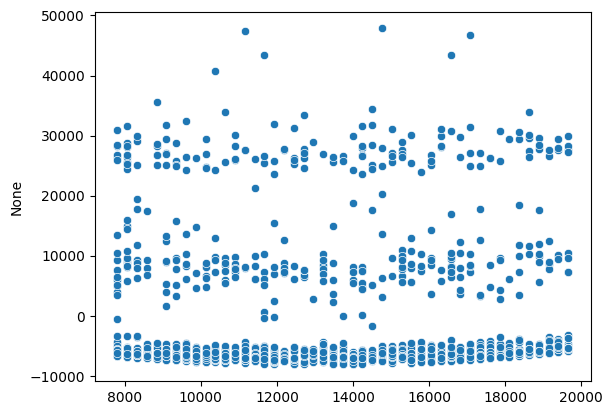

In [15]:
# Plot Residuals -- three tiers here to try to predict with new features

sns.scatterplot(x=model.predict(), y=model.resid)